### Advanced Python: Applied AI/ML Techniques
#### Day 6: Planned Topics

#### Advanced CNN Architectures (overview)
- VGG
- ResNet
- EfficientNet

#### Transfer Learning and Fine-tuning
- Exploring pretrained models in torchvision
- Using timm for pretrained models
- Transfer-Learning and Fine-tuning techniques

#### An overview on Generative AI models
- An overview of Diffusion model


---

### Advanced CNN Architectures

#### VGG - Visual Geometry Group

VGG, short for Visual Geometry Group, refers to a family of deep convolutional neural network architectures developed by the Visual Geometry Group at the University of Oxford. Specifically, VGG-16 and VGG-19 are widely recognized and used, particularly for transfer learning in tasks like image classification and face recognition. 

VGG is a neural network model that uses convolutional neural network (CNN) layers and was designed for the [ImageNet challenge](http://www.image-net.org/challenges/LSVRC/), which it won in 2014.

VGG is not a single model, but a family of models that are all similar but have different *configurations*. Each configuration specifies the number of layers and the size of each layer. The configurations are listed in table 1 of the [VGG paper](https://arxiv.org/pdf/1409.1556.pdf) and denoted by a letter, although recently they are just referred to as the number of layers with weights in the model, e.g. configuration "A" has 11 layers with weights so is known as VGG11.

![](https://github.com/bentrevett/pytorch-image-classification/blob/master/assets/vgg-table.png?raw=1)

Below is the architecture of configuration "D", also known as VGG16, for a 224x224 color image.

![](https://github.com/bentrevett/pytorch-image-classification/blob/master/assets/vgg.png?raw=1)

The other commonly used VGG variants are VGG11, VGG13 and VGG19, which correspond to configurations "A", "B", and "E". Configurations "A-LRN" and "C" - which is the same as "D" but with smaller filter sizes in some convolutional layers - are rarely used.

Usually we will initialize our weights randomly - following some weight initialization scheme - and then train our model. Using a pre-trained model means some - potentially all - of our model's weights are not initialized randomly, but instead taken from a copy of our model that has already been trained on some task. The task the model has been pre-trained on does not necessarily have to match the "downstream task" - the task we want to use the pre-trained model on. For example, a model that has been trained to classify images can then be used to detect objects within an image.

The theory is that these pre-trained models have already learned high level features within images that will be useful for our task. This means we don't have to learn them from scratch when using the pre-trained model for our task, causing our model to converge earlier. We can also think of the pre-trained model as being a very good set of weights to initialize our model from, and using pre-trained models usually leads to a performance improvement compared to initializing our weights randomly. 

The act of using a pre-trained model is generally known as *transfer learning*, as we are learning to transfer knowledge from one task to another. It is also referred to as *fine-tuning*, as we fine-tune our parameters trained on one task to the new, downstream task. The terms *transfer learning* and *fine-tuning* are used interchangeably in machine learning. 

### Defining the Model

Usually the next thing we'd do is load our data, however this is quite different when using a pre-trained model, so we'll first introduce the VGG architecture and then show how to load a pre-trained VGG model.

Below is the general VGG model. This is the part of VGG that is common for all VGG configurations. The only part that depends on the configuration is the `features`, which we will pass as an argument when we construct the VGG model.

The only new feature introduced here in the `AdaptiveAvgPool2d`. As well as the standard `AvgPool` and `MaxPool` layers, PyTorch has "adaptive" versions of those layers. In adaptive pooling layers we specify the desired output size of the pooling layer instead of the size of the filter used by the pooling layer. Here, we want an output size of 7x7. We know that all VGG configurations end with a convolutional layer that has 512 filters, thus if our `features` layer for each configuration always has a size of 7x7 we do not have to change the `classifier` for each VGG configuration. The advantage of using adaptive layers is that it allows us to apply our model to images of different sizes - down to a minimum size, which is 32x32 in VGG models.

**Note:** even though VGG net can handle images as small as 32x32 it is designed to give optimal performance for larger images. We handle this later on in this tutorial.

How do the adaptive pooling layers calculate the size of their filters? For each dimension, i.e. height and width, we calculate:

```
filter_size = (input_size + desired_size - 1) // desired_size
```

`//` means we round down to the nearest integer. So, if we wanted to filter a 32x32 image to 7x7 we would have a 6x6 filter. When the filter is applied to the image it will need to overlap at some points, i.e. some pixels will be covered by the filter twice. To calculate the positions of the filter we split the 32x32 image into `desired_size` evenly spaced points. 

This can be calculated with `np.linspace(0, input_size - desired_size, desired_size)` which for our example gives us: `[0, 4.16666667, 8.33333333, 12.5, 16.66666667, 20.83333333, 25]`. We then round each of these points down to the nearest integer as we cannot have a filter cover a fraction of a pixel, which gives us: `[0, 4, 8, 12, 16, 20, 25]`. Thus, the 6x6 filter covers pixels: 0-5, 4-10, 8-14, 12-18, 16-22, 20-26 and 25-31 in each dimension.

Let's define the VGG base architecture. 

In [2]:
import torch
from torch import nn


In [3]:
class VGG(nn.Module):
    def __init__(self, features, output_dim):
        super().__init__()

        self.features = features

        self.avgpool = nn.AdaptiveAvgPool2d(7)

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, output_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.classifier(h)
        return x, h

Next up is calculating the `features` for each VGG configuration.

Typically the VGG configurations are defined as lists. Each item in the list is either 'M', which denotes a max pooling layer, or an integer, which denotes a convolutional layer with that many filters.

Below are the configurations for VGG11, VGG13, VGG16 and VGG19. Otherwise known as configurations "A", "B", "D" and "E", respectively.

In [4]:
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512,
                512, 'M']

vgg16_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512,
                'M', 512, 512, 512, 'M']

vgg19_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512,
                512, 512, 'M', 512, 512, 512, 512, 'M']

In [5]:
def get_vgg_layers(config, batch_norm):

    layers = []
    in_channels = 3

    for c in config:
        assert c == 'M' or isinstance(c, int)
        if c == 'M':
            layers += [nn.MaxPool2d(kernel_size=2)]
        else:
            conv2d = nn.Conv2d(in_channels, c, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = c

    return nn.Sequential(*layers)

In [6]:
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm=True)

In [7]:
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

In [8]:
vgg19_layers = get_vgg_layers(vgg19_config, batch_norm=True)
vgg19_layers

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU(inplace=True)
  (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU(inplace=True)
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

We can then pass these `features` to our base VGG module to get our VGG11 model.

In [ ]:
OUTPUT_DIM = 10

model = VGG(vgg11_layers, OUTPUT_DIM)

print(model)

In [10]:
from torchvision import models
vgg11 = models.vgg11_bn(weights=models.VGG11_BN_Weights.IMAGENET1K_V1)
print(vgg11)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

---

#### ResNet - Residual Network

ResNet, short for Residual Network, is a type of deep learning architecture that uses "skip connections" (also known as residual connections) to overcome the vanishing gradient problem and enable the training of extremely deep convolutional neural networks. These connections allow the network to learn residual functions, effectively allowing the network to skip or bypass layers during the forward pass. 

ResNet, like VGG, also has multiple *configurations* which specify the number of layers and the sizes of those layers. Each layer is made out of *blocks*, which are made up of convolutional layers, batch normalization layers and *residual connections* (also called *skip connections* or *shortcut connections*). Confusingly, ResNets use the term "layer" to refer to both a set of blocks, e.g. "layer 1 has two blocks", and also the total number of layers within the entire ResNet, e.g. "ResNet18 has 18 layers".

A residual connection is simply a direct connection between the input of a block and the output of a block. Sometimes the residual connection has layers in it, but most of the time it does not. Below is an example block with an identity residual connection, i.e. no layers in the residual path.

![image](assets/resnet-skip.png)

The different ResNet configurations are known by the total number of layers within them - ResNet18, ResNet34, ResNet50, ResNet101 and ResNet152. 

![image](assets/resnet-table.png)

From the table above, we can see that for ResNet18 and ResNet34 that the first block contains two 3x3 convolutional layers with 64 filters, and that ResNet18 has two of these blocks in the first layer, whilst Resnet34 has three. ResNet50, ResNet101 and ResNet152 blocks have a different structure than those in ResNet18 and ResNet34, and these blocks are called *bottleneck* blocks. Bottleneck blocks reduce the number of number of channels within the input before expanding them back out again. Below shows a standard *BasicBlock* (left) - used by ResNet18 and ResNet34 - and the *Bottleneck* block used by ResNet50, ResNet101 and ResNet152.

![image](assets/resnet-blocks.png)

Why do ResNets work? The key is in the residual connections. Training incredibly deep neural networks is difficult due to the gradient signal either exploding (becoming very large) or vanishing (becoming very small) as it gets backpropagated through many layers. Residual connections allow the model to learn how to "skip" layers - by setting all their weights to zero and only rely on the residual connection. Thus, in theory, if your ResNet152 model can actually learn the desired function between input and output by only using the first 52 layers the remaining 100 layers should set their weights to zero and the output of the 52nd layer will simply pass through the residual connections unhindered. This also allows for the gradient signal to also backpropagate through those 100 layers unhindered too. This outcome could also also be achieved in a network without residual connections, the "skipped" layers would learn to set their weights to one, however adding the residual connection is more explicit and is easier for the model to learn to use these residual connections.


In [ ]:
# Using ResNet18 (Residual Network)
model = models.resnet18(weights='DEFAULT')
model


In [ ]:
dir(models.ResNet50_Weights)

In [ ]:
# Change the final layer to match the number of classes in our dataset
model = models.resnet18(weights='DEFAULT')

# Freeze all layers except the final layer
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, training_data.num_classes)
for param in model.fc.parameters(): # Not required as we are replacing it
    param.requires_grad = True
model = model.to(device)


In [ ]:
# Change the final layer to match the number of classes in our dataset
model = models.resnet50(weights='DEFAULT')

# Freeze all layers except the final layer
#for param in model.parameters():
#    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, training_data.num_classes)
#for param in model.fc.parameters(): # Not required as we are replacing it
#    param.requires_grad = True
model = model.to(device)


In [ ]:
best_valid_loss = float('inf')

from tqdm.notebook import trange
def train_model(model, train_loader, loss_fn, optimizer, num_epochs=5):
  
    for epoch in trange(num_epochs):
        training_loss = 0.0
        validation_loss = 0.0
        
        # Train the model
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            training_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {training_loss/len(train_loader):.8f}")

        # Validate the model
        model.eval()
        with torch.no_grad():
            for images, labels in validate_data_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                validation_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {validation_loss/len(validate_data_loader):.8f}")

        # Save the model if validation loss has decreased
        global best_valid_loss
        if validation_loss < best_valid_loss:
            best_valid_loss = validation_loss
            torch.save(model.state_dict(), "best_model.pth")
            print(f"Validation loss decreased, saving model.")

train_model(model, training_data_loader, loss_fn, optimizer, num_epochs=7)

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

def evaluate_model(model, test_loader):
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Accuracy: {100 * correct / total:4.2f}%")
evaluate_model(model, testing_data_loader)

In [ ]:

class ChessManResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet18(weights="ResNet18_Weights.IMAGENET1K_V1")
        self.resnet.fc = nn.Linear(512, training_data.num_classes)  # Change the final fully connected layer for 6 classes

    def forward(self, x):
        return self.resnet(x)

model = ChessManResNet().to(device)

#for param in model.parameters():  # Freeze pretrained model parameters
#    param.requires_grad = False

loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
def train_model(model, train_loader, loss_fn, optimizer, num_epochs=5):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.8f}")

train_model(model, training_data_loader, loss_fn, optimizer, num_epochs=8)

In [ ]:

def evaluate_model(model, test_loader):
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Accuracy: {100 * correct / total:4.2f}%")
evaluate_model(model, testing_data_loader)

---

### EfficientNet

EfficientNet is a family of convolutional neural networks (CNNs) developed by Google (2019) that achieves state-of-the-art accuracy in image classification while being significantly smaller and faster than previous models. It uses a "compound scaling" method to uniformly balance network depth, width, and resolution. This approach allows for efficient scaling, achieving up to 8.4x smaller size and 6.1x faster inference than traditional CNNs like ResNet.

![EfficientNet Architecture](./assets/efficientNet.webp)

#### Key Aspects of EfficientNet
 * **Compound Scaling Method:** Unlike traditional methods that scale only one dimension (e.g., depth), EfficientNet uses a compound coefficient to scale all three dimensions—depth, width, and resolution—proportionally.
 * **Performance & Efficiency:** The *EfficientNet-B7* model achieved a state-of-the-art 84.4% top-1 accuracy on ImageNet while being much faster and more efficient.
 * **Architecture (B0-B7):** The family starts with a baseline, EfficientNet-B0, developed using Neural Architecture Search (NAS). Subsequent models (B1-B7) are scaled up versions of this base.
 * **Use Cases:** Primarily designed for image classification, but widely used for transfer learning in object detection and image segmentation tasks.
 * **Transfer Learning:** EfficientNet models perform exceptionally well on other datasets, achieving high accuracy on datasets like CIFAR-100 and Flowers. 

 EfficientNet uses Swish Activation functions instead of ReLU.
 ![Swish Activation Function](./assets/Self-Gated-Swish-Activation-Function.webp)

EfficientNet is considered a robust choice for computer vision tasks requiring high accuracy on limited computational resources.

For detailed paper: https://arxiv.org/pdf/1905.11946

---

### Using Pre-trained Models

Using a pre-trained model involves initializing our model with parameters that have already been trained for a certain task - usually not the exact same task we are trying to do ourselves.

Torchvision has ways to easily download a pre-trained model. We simply import the `torchvision.models` package, specify which model we want to use and then pass the argument `pretrained = True`. We can see a list of all available pre-trained models provided by torchvision [here](https://pytorch.org/vision/stable/models.html). 

Let's import a pre-trained VGG11 with batch normalization. The first time this code is run the pre-trained parameters will be downloaded and are around 140MB for VGG11 with batch normalization.

In [45]:
from torchvision import models
from torchvision import datasets, transforms

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

As we can see, the pre-trained model loaded is exactly the same as the one we have defined with one exception - the output of the final linear layer. 

All of torchvision's pre-trained models are trained as image classification models on the [ImageNet](http://www.image-net.org/challenges/LSVRC/) dataset. A dataset of 224x224 color images with 1000 classes, therefore the final layer will have a 1000 dimensional output.

We can get the last layer specifically by indexing into the `classifier` layer of the pre-trained model.

Let us fine-tune these models to classify images from CIFAR10 dataset.

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
train_data.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

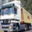

In [22]:
train_data[1][0]

In [23]:
len(train_data)

50000

In [25]:
model.classifier.append(nn.Linear(1000, 512))

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
  (2): Linear(in_features=1000, out_features=512, bias=True)
)

In [26]:
model.classifier.append(nn.ReLU(inplace=True))

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
  (2): Linear(in_features=1000, out_features=512, bias=True)
  (3): ReLU(inplace=True)
)

In [46]:
layer_sizes = [(1000, 512), (512, 256), (256, 10)]

for in_features, out_features in layer_sizes:
    model.classifier.append(nn.ReLU(inplace=True))
    model.classifier.append(nn.Linear(in_features, out_features))
    
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
  (2): ReLU(inplace=True)
  (3): Linear(in_features=1000, out_features=512, bias=True)
  (4): ReLU(inplace=True)
  (5): Linear(in_features=512, out_features=256, bias=True)
  (6): ReLU(inplace=True)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

In [28]:
model.classifier.insert(2, nn.ReLU(inplace=True))

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
  (2): ReLU(inplace=True)
  (3): Linear(in_features=1000, out_features=512, bias=True)
  (4): ReLU(inplace=True)
  (5): Linear(in_features=512, out_features=256, bias=True)
  (6): ReLU(inplace=True)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

In [ ]:
# Enable gradient computation for the newly added layers
for layer in model.classifier[1:].parameters():
    layer.requires_grad_ = True

In [ ]:
import torch

a = torch.tensor([1, 2, 3], dtype=torch.float, requires_grad=True)
print(a)
a.requires_grad_

tensor([1., 2., 3.], requires_grad=True)


True

In [50]:
# Disable gradient computation for the pretrained layers (Freezing)
for layer in model.features.parameters():
    layer.requires_grad_(False)
    print(layer)
    print("-" * 40)

Parameter containing:
tensor([[[[ 1.2156e-01,  6.5634e-01,  4.5671e-01],
          [-1.1092e-01, -6.1004e-01, -3.3345e-01],
          [ 2.7964e-02, -1.0312e-01, -1.0324e-01]],

         [[ 6.3553e-02,  1.6552e+00,  1.7436e+00],
          [-1.3646e-01, -1.5367e+00, -1.5937e+00],
          [ 5.0196e-02, -1.1360e-01, -1.2600e-01]],

         [[ 8.7276e-02,  3.6126e-01,  2.6946e-01],
          [-1.1966e-01, -2.8122e-01, -2.1883e-01],
          [ 3.6658e-02, -7.0751e-02, -8.1917e-02]]],


        [[[ 1.6449e-01, -2.0041e-01,  8.3092e-02],
          [ 8.9009e-01, -1.2110e+00,  2.7610e-01],
          [ 1.0740e+00, -1.2603e+00,  2.0645e-01]],

         [[ 3.2816e-01, -4.3449e-01,  1.8769e-01],
          [ 1.6213e+00, -2.1188e+00,  4.1014e-01],
          [ 1.7230e+00, -2.0756e+00,  3.3958e-01]],

         [[ 9.5290e-02, -1.5971e-01,  7.4559e-02],
          [ 8.0502e-01, -9.7034e-01,  2.6280e-01],
          [ 7.1944e-01, -1.0026e+00,  1.9870e-01]]],


        [[[ 5.3857e-02,  2.6367e-01,  1.1696

In [39]:
p = model.features.parameters()
layer = next(p)
print(layer)

Parameter containing:
tensor([[[[ 1.2156e-01,  6.5634e-01,  4.5671e-01],
          [-1.1092e-01, -6.1004e-01, -3.3345e-01],
          [ 2.7964e-02, -1.0312e-01, -1.0324e-01]],

         [[ 6.3553e-02,  1.6552e+00,  1.7436e+00],
          [-1.3646e-01, -1.5367e+00, -1.5937e+00],
          [ 5.0196e-02, -1.1360e-01, -1.2600e-01]],

         [[ 8.7276e-02,  3.6126e-01,  2.6946e-01],
          [-1.1966e-01, -2.8122e-01, -2.1883e-01],
          [ 3.6658e-02, -7.0751e-02, -8.1917e-02]]],


        [[[ 1.6449e-01, -2.0041e-01,  8.3092e-02],
          [ 8.9009e-01, -1.2110e+00,  2.7610e-01],
          [ 1.0740e+00, -1.2603e+00,  2.0645e-01]],

         [[ 3.2816e-01, -4.3449e-01,  1.8769e-01],
          [ 1.6213e+00, -2.1188e+00,  4.1014e-01],
          [ 1.7230e+00, -2.0756e+00,  3.3958e-01]],

         [[ 9.5290e-02, -1.5971e-01,  7.4559e-02],
          [ 8.0502e-01, -9.7034e-01,  2.6280e-01],
          [ 7.1944e-01, -1.0026e+00,  1.9870e-01]]],


        [[[ 5.3857e-02,  2.6367e-01,  1.1696

In [34]:
for layer in model.features.parameters():
    print(layer)
    print("-" * 40)

Parameter containing:
tensor([[[[ 1.2156e-01,  6.5634e-01,  4.5671e-01],
          [-1.1092e-01, -6.1004e-01, -3.3345e-01],
          [ 2.7964e-02, -1.0312e-01, -1.0324e-01]],

         [[ 6.3553e-02,  1.6552e+00,  1.7436e+00],
          [-1.3646e-01, -1.5367e+00, -1.5937e+00],
          [ 5.0196e-02, -1.1360e-01, -1.2600e-01]],

         [[ 8.7276e-02,  3.6126e-01,  2.6946e-01],
          [-1.1966e-01, -2.8122e-01, -2.1883e-01],
          [ 3.6658e-02, -7.0751e-02, -8.1917e-02]]],


        [[[ 1.6449e-01, -2.0041e-01,  8.3092e-02],
          [ 8.9009e-01, -1.2110e+00,  2.7610e-01],
          [ 1.0740e+00, -1.2603e+00,  2.0645e-01]],

         [[ 3.2816e-01, -4.3449e-01,  1.8769e-01],
          [ 1.6213e+00, -2.1188e+00,  4.1014e-01],
          [ 1.7230e+00, -2.0756e+00,  3.3958e-01]],

         [[ 9.5290e-02, -1.5971e-01,  7.4559e-02],
          [ 8.0502e-01, -9.7034e-01,  2.6280e-01],
          [ 7.1944e-01, -1.0026e+00,  1.9870e-01]]],


        [[[ 5.3857e-02,  2.6367e-01,  1.1696

As our dataset, CIFAR10, only has 10 classes then we want the last layer to have a 10 dimensional output. 

We'll define a new final linear layer which has to have an input size equal to that of the layer we are replacing - as it's input will be the 4096 dimensional output from the previous linear layer in the classifier. The output of this linear layer will be 10 dimensions - as our dataset has 10 classes.

In [51]:
ROOT = '../../data'

train_data = datasets.CIFAR10(root=ROOT,
                              train=True,
                              download=True)

means = [0.485, 0.456, 0.406]
stds = [0.229, 0.224, 0.225]

resize_size = 256
crop_size = 224

print(f'Calculated means: {means}')
print(f'Calculated stds: {stds}')


Calculated means: [0.485, 0.456, 0.406]
Calculated stds: [0.229, 0.224, 0.225]


/opt/anaconda3/envs/2026_Apr16/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [65]:
train_transforms = transforms.Compose([
                            transforms.Resize(resize_size, 
                                              interpolation=transforms.InterpolationMode.BICUBIC),
                            transforms.CenterCrop(crop_size),
                            transforms.ToTensor(),
                            transforms.Normalize(mean=means, std=stds)
                                      ])

test_transforms = transforms.Compose([
                           transforms.Resize(resize_size, 
                                             interpolation=transforms.InterpolationMode.BICUBIC),
                           transforms.CenterCrop(crop_size),
                           transforms.ToTensor(),
                           transforms.Normalize(mean=means, std=stds)
                                     ])

print(train_transforms)
print(test_transforms)

Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [66]:
from torch.utils.data import random_split

train_data = datasets.CIFAR10(root=ROOT,
                              train=True,
                              download=True,
                              transform=train_transforms)

print(len(train_data))

train_data, validate_data = random_split(train_data, [40000, 10000])

test_data = datasets.CIFAR10(root=ROOT,
                             train=False,
                             download=True,
                             transform=test_transforms)

validate_data.dataset.transform = test_transforms


train_data, validate_data, test_data



/opt/anaconda3/envs/2026_Apr16/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


50000


(<torch.utils.data.dataset.Subset at 0x35656f390>,
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: ../../data
     Split: Test
     StandardTransform
 Transform: Compose(
                Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
                CenterCrop(size=(224, 224))
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ))

In [84]:
from torch.utils import data

BATCH_SIZE = 4

train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE)

valid_iterator = data.DataLoader(validate_data,
                                 batch_size=BATCH_SIZE)

test_iterator = data.DataLoader(test_data,
                                batch_size=BATCH_SIZE)

In [60]:
(256 * 256 * 3 * 8192) / (1024 * 1024 * 1024)

1.5

In [61]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [62]:
count_parameters(model)

1927410

In [68]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()



In [69]:
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

In [86]:
def train(model, iterator, optimizer, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in tqdm(iterator, desc="Training", leave=False):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_pred = model(x)

        loss = criterion(y_pred, y)

        acc = calculate_accuracy(y_pred, y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [87]:
def validate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [72]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
EPOCHS = 5
import time
from tqdm.notebook import tqdm
from tqdm.notebook import trange

best_valid_loss = float('inf')

device = torch.accelerator.current_accelerator() \
         if torch.accelerator.is_available() else torch.device('cpu')

model.to(device)

for epoch in trange(EPOCHS):

    start_time = time.monotonic()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = validate(model, valid_iterator, criterion, device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'effnet_tuned.pt')

    end_time = time.monotonic()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

  0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

We can directly overwrite the previous linear layer with our new linear layer. 

Note that our `final_fc` will be initialized randomly. It is the only part of our model with its parameters not pre-trained.

In [ ]:
# pretrained_model.classifier[-1] = final_fc

We can then print out the `classifier` of our model to ensure the final linear layer now has an output dimension of 10.

In [ ]:
# print(pretrained_model.classifier)

We could go ahead and use the `pretrained_model` module from here on out, however it only returns the final output layer and not the intermediate representation as our `model` does. We can see that in the model's definition [here](https://github.com/pytorch/vision/blob/master/torchvision/models/vgg.py#L47). 

We can load the parameters of the `pretrained_model` into our `model` by loading the parameters (`state_dict`) from the `pretrained_model` into our `model` in the same way we loaded the "best" saved parameters in the previous notebooks - by using `load_state_dict`. However, this time we load directly from the `pretrained_model` instead of using `torch.load` on the path of the saved model parameters. 

This is only possible as our `model` has the exact same layers (order and shape) as the `pretrained_model` with the final linear layer replaced with our 10 dimensional output linear layer.

In [ ]:
model.load_state_dict(pretrained_model.state_dict())

This model has considerably more parameters than the previous model, AlexNet - 128M compared to 23M.

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f'The model has {count_parameters(model):,} trainable parameters')

Instead of training all the parameters we have loaded from a pre-trained model, we could instead only learn some of them and leave some "frozen" at their pre-trained values. As our model will then have less trainable parameters it will usually train faster and we can usually fit it on smaller GPUs. 

We aren't going to freeze any parameters in this notebook, but if we wanted to freeze the `features` layer then we could do that with:

```python
for parameter in model.features.parameters():
    parameter.requires_grad = False
```

We could also freeze the `classifier` layer, however we always want to train the last layer as this is what we have initialized randomly and needs to be trained. Freezing all but the last layer in the `classifier` can be done with:

```python
for parameter in model.classifier[:-1].parameters():
    parameter.requires_grad = False
```

---

### Transfer Learning using ```timm```

In [ ]:
conda install timm -y

In [ ]:
import timm
timm.__version__

In [ ]:
len(models.list_models())

In [ ]:
len(timm.list_models())

In [ ]:
len(timm.list_pretrained())

In [ ]:
timm.list_models("resnet*")

In [ ]:
timm.list_pretrained("resnet*")

In [ ]:
timm.create_model?

In [ ]:
m = timm.create_model("efficientnet_b0", pretrained=True)
m


In [ ]:


g = m.children()


In [ ]:
next(g)

In [ ]:
6 * 224

In [ ]:
#[ t for t in timm.list_models(pretrained=True) if t.startswith("resnet") ]
timm.list_models("resnet*")

In [ ]:
m

In [ ]:
m.classifier.in_features

In [ ]:
import timm
class SimpleChessManClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # self.base_model = models.resnet18(weights='DEFAULT')
        self.base_model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        num_ftrs = self.base_model.classifier.in_features
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_ftrs, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
model

In [ ]:
# Fine-tuning a pretrained model with timm, without classes and other artificats.

model = timm.create_model("efficientnet_b0", pretrained=True, 
                          num_classes=training_data.num_classes)


# Freezing a pretrained model
for child in model.children():
   child.requires_grad = False


num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, training_data.num_classes)

model = model.to(device)


In [ ]:
loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model = SimpleChessManClassifier(num_classes=training_data.num_classes).to(device)

loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Freezing a pretrained model
#for child in model.features.children():
#    child.requires_grad = False
    


In [ ]:
len(list(model.children()))

In [ ]:
len(timm.list_models(pretrained=True))

In [ ]:
best_valid_loss = float('inf')

from tqdm.notebook import trange
def train_model(model, train_loader, loss_fn, optimizer, num_epochs=5):
  
    for epoch in trange(num_epochs):
        training_loss = 0.0
        validation_loss = 0.0
        
        # Train the model
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            training_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {training_loss/len(train_loader):.8f}")

        # Validate the model
        model.eval()
        with torch.no_grad():
            for images, labels in validate_data_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                validation_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {validation_loss/len(validate_data_loader):.8f}")

        # Save the model if validation loss has decreased
        global best_valid_loss
        if validation_loss < best_valid_loss:
            best_valid_loss = validation_loss
            torch.save(model.state_dict(), "best_model.pth")
            print(f"Validation loss decreased, saving model.")

train_model(model, training_data_loader, loss_fn, optimizer, num_epochs=7)

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

def evaluate_model(model, test_loader):
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Accuracy: {100 * correct / total:4.2f}%")
evaluate_model(model, testing_data_loader)

##### Visualizing transforms

In [ ]:
from PIL import Image
img = Image.open('data/Chessman-image-dataset/Chess/King/00000061.jpg')


In [ ]:
import PIL.ImagePath
import torchvision.transforms.functional as tvf
import PIL
import torchvision.transforms as transforms

def visualize_transforms(image, transforms):
    fig, axes = plt.subplots(1, len(transforms) + 1, figsize=(15, 5))
    axes[0].imshow(tvf.to_pil_image(image))
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    for i, transform in enumerate(transforms):
        transformed_image = transform(image)
        axes[i + 1].imshow(tvf.to_pil_image(transformed_image))
        axes[i + 1].set_title(f"Transform {i + 1}")
        axes[i + 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage of visualize_transforms
#example_image, _ = training_data[90]
example_image = transforms.PILToTensor()(PIL.Image.open('data/Chessman-image-dataset/Chess/King/00000061.jpg'))
#example_image = tvf.convert_image_dtype(example_image, dtype=torch.float32)
transforms_list = [
    tvf.autocontrast,
    tvf.equalize,
    transforms.AutoAugment(
        transforms.AutoAugmentPolicy.IMAGENET,
        interpolation=PIL.Image.BILINEAR
    ),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
]
visualize_transforms(example_image, transforms_list)

In [ ]:
plt.imshow(example_image[2], cmap="bone")

In [ ]:
#print(example_image.float())
mean, std = example_image.float()[0].mean(), example_image.float()[0].std()
(example_image - mean) / std

In [ ]:
fn = transforms.Normalize([100., 100., 100.], [25., 78., 28])
fn(example_image.float())

---

### Introduction to Generative AI models

Generative AI models can take inputs such as text, image, audio, video, and code and generate new content into any of the modalities mentioned. For example, it can turn text inputs into an image, turn an image into a song, or turn video into text.

**GANs**

Generative Adversarial Networks (GANs) are a type of deep learning architecture that use two neural networks – a generator and a discriminator – to generate new data that resembles a given training dataset. The generator creates new data samples, while the discriminator tries to distinguish between real and generated data. This adversarial process forces the generator to produce increasingly realistic data, eventually fooling the discriminator. 


**Diffusion Models**

Diffusion models are a type of generative AI model that creates new data, like images or audio, by gradually adding noise to existing data and then learning to reverse that process. They work by learning to remove the added noise, transforming it back into a structured output. This process is often used to generate high-quality, realistic images from text prompts.

![image](./assets/diffusion2.png)



In [ ]:
# Simplest Diffusion Model Demonstration in PyTorch
# Training on a simple 2D circle image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import math

print("=== Simple Diffusion Model Demo ===\n")

# Set device for Apple Silicon
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Step 1: Create a simple 2D image (circle)
def create_circle_image(size=32, radius=0.3):
    """Create a simple 2D circle image"""
    x = torch.linspace(-1, 1, size)
    y = torch.linspace(-1, 1, size)
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    
    # Create smooth circle with values in [-1, 1] range
    distances = torch.sqrt(xx**2 + yy**2)
    circle = torch.exp(-((distances - radius) ** 2) / (2 * 0.1**2))  # Gaussian falloff
    circle = 2 * circle - 1  # Normalize to [-1, 1]
    return circle.float()

# Create our simple dataset
class CircleDataset(Dataset):
    def __init__(self, num_samples=1000, image_size=32):
        self.num_samples = num_samples
        self.image_size = image_size
        self.base_image = create_circle_image(image_size)
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Add small random variations to make learning more robust
        noise = torch.randn_like(self.base_image) * 0.1
        return self.base_image + noise

# Create dataset and dataloader
dataset = CircleDataset(num_samples=1000)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Visualize the original image
original_image = dataset.base_image

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(original_image.numpy(), cmap='gray')
plt.title('Original Circle Image')
plt.colorbar()


In [ ]:

# Step 2: Define the Diffusion Process with Cosine Noise Schedule
class SimpleDiffusion:
    def __init__(self, timesteps=1000, device='mps'):
        self.timesteps = timesteps
        self.device = device
        
        # Use cosine schedule (better than linear)
        self.betas = self._cosine_beta_schedule(timesteps).to(device, dtype=torch.float32)
        
        # Precompute values
        self.alphas = 1. - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1. - self.alpha_bars)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        
    def _cosine_beta_schedule(self, timesteps, s=0.008):
        """Cosine schedule as proposed in Improved DDPM paper"""
        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0, 0.999)
    
    def add_noise(self, x_0, t):
        sqrt_alpha_bar = self.sqrt_alpha_bars[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar = self.sqrt_one_minus_alpha_bars[t].view(-1, 1, 1, 1)
        
        noise = torch.randn_like(x_0, dtype=torch.float32)
        x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise
        
        return x_t, noise
    
    def sample_timesteps(self, batch_size):
        return torch.randint(0, self.timesteps, (batch_size,), device=device, dtype=torch.long)

# Initialize diffusion process with proper data types
diffusion = SimpleDiffusion(timesteps=1000, device=device)
print(f"Diffusion process initialized with {diffusion.timesteps} timesteps")


In [ ]:
# Step 3: Define Simple Denoising Network Residual Connections
class SimpleDenoiser(nn.Module):
    def __init__(self, image_size=32):
        super().__init__()
        self.image_size = image_size
        
        self.initial_conv = nn.Conv2d(2, 128, 3, padding=1)
        
        self.res_block1 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
        )
        
        self.res_block2 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
        )
        
        self.final_conv = nn.Conv2d(128, 1, 3, padding=1)
        
        # Improved timestep embedding
        self.timestep_embed = nn.Sequential(
            nn.Linear(1, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, image_size * image_size)
        )
        
    def forward(self, x, t):
        # Timestep embedding
        t_embed = self.timestep_embed(t.float().unsqueeze(1))
        t_embed = t_embed.view(-1, 1, self.image_size, self.image_size)
        
        # Concatenate and process
        x_with_time = torch.cat([x, t_embed], dim=1)
        x = self.initial_conv(x_with_time)
        
        # Residual blocks with skip connections
        residual = x
        x = self.res_block1(x)
        x = x + residual
        
        residual = x
        x = self.res_block2(x)
        x = x + residual
        
        return self.final_conv(x)

# Initialize model and move to MPS
model = SimpleDenoiser(image_size=32).to(device)
print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")


In [ ]:
# Step 4: Create a sample diffusion step
@torch.no_grad()
def sample_diffusion(model, diffusion, image_size=32, num_samples=1, ddim=True):
    model.eval()
    
    x = torch.randn(num_samples, 1, image_size, image_size, device=device, dtype=torch.float32)
    intermediate_images = [x.cpu().numpy()]
    
    if ddim:
        # DDIM (Denoising Diffusion Implicit Models) sampling (faster and often better quality)
        sampling_steps = 50  # Much fewer steps than training
        step_size = diffusion.timesteps // sampling_steps
        
        for t in reversed(range(0, diffusion.timesteps, step_size)):
            t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
            
            predicted_noise = model(x, t_tensor)
            
            alpha_bar_t = diffusion.alpha_bars[t]
            alpha_bar_t_prev = diffusion.alpha_bars[t - step_size] if t > step_size else torch.tensor(1.0)
            
            if t > 0:
                noise = torch.randn_like(x, dtype=torch.float32)
            else:
                noise = torch.zeros_like(x, dtype=torch.float32)
            
            # DDIM update rule
            x = (torch.sqrt(alpha_bar_t_prev) * 
                (x - torch.sqrt(1 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_bar_t) +
                torch.sqrt(1 - alpha_bar_t_prev) * predicted_noise)
            
            if t % 100 == 0 or t < 20:
                intermediate_images.append(x.cpu().numpy())
    else:
        # Original DDPM (Denoising Diffusion Probabilistic Models) sampling
        for t in reversed(range(diffusion.timesteps)):
            t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
            predicted_noise = model(x, t_tensor)
            
            alpha_t = diffusion.alphas[t]
            alpha_bar_t = diffusion.alpha_bars[t]
            
            if t > 0:
                noise = torch.randn_like(x, dtype=torch.float32)
            else:
                noise = torch.zeros_like(x, dtype=torch.float32)
            
            x = (1 / torch.sqrt(alpha_t)) * (
                x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * predicted_noise
            ) + torch.sqrt(diffusion.betas[t]) * noise
            
            if t % 100 == 0 or t < 10:
                intermediate_images.append(x.cpu().numpy())
    
    return x, intermediate_images


In [ ]:
# Step 5: Training Loop with Learning Rate Scheduling

from tqdm.notebook import tqdm, trange
def train_diffusion(model, dataloader, diffusion, epochs=1000):
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    
    model.train()
    losses = []
    
    for epoch in trange(epochs):
        epoch_loss = 0
        
        for clean_images in dataloader:
            clean_images = clean_images.unsqueeze(1).to(device, dtype=torch.float32)
            
            # Sample timesteps with more emphasis on middle timesteps
            t = diffusion.sample_timesteps(clean_images.size(0))
            
            # Add noise
            noisy_images, true_noise = diffusion.add_noise(clean_images, t)
            
            # Predict noise
            predicted_noise = model(noisy_images, t)
            
            # Loss with timestep weighting (focus on harder timesteps)
            loss = criterion(predicted_noise, true_noise)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
            optimizer.step()
            
            epoch_loss += loss.item()
        
        scheduler.step()
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        
        if epoch % 100 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch}/{epochs}, Loss: {avg_loss:.6f}, LR: {current_lr:.2e}")
            
            # Generate sample to monitor progress
            with torch.no_grad():
                sample, _ = sample_diffusion(model, diffusion, num_samples=1)
                sample_mse = ((sample - clean_images[:1]) ** 2).mean().item()
                print(f"  Sample MSE: {sample_mse:.6f}")
    
    return losses

print("\n=== Training Diffusion Model ===")
losses = train_diffusion(model, dataloader, diffusion, epochs=500)

# Plot training loss
plt.subplot(1, 3, 2)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)


In [ ]:
# Step 6: Sample Generation Process 

print("\n=== Generating Samples ===")
generated_images, intermediate_steps = sample_diffusion(model, diffusion, num_samples=1)

# Visualize generated image
plt.subplot(1, 3, 3)
plt.imshow(generated_images[0, 0].cpu().numpy(), cmap='gray', vmin=-1, vmax=1)
plt.title('Generated Image')
plt.colorbar()

plt.tight_layout()
plt.show()


In [ ]:

# Step 7: Demonstrate Forward Diffusion (Adding Noise)
def visualize_forward_diffusion(original_image, diffusion, num_steps=6):
    """Visualize the forward diffusion process (adding noise)"""
    original_batch = original_image.unsqueeze(0).unsqueeze(0).to(device, dtype=torch.float32)
    
    plt.figure(figsize=(15, 3))
    plt.suptitle('Forward Diffusion Process: Adding Noise Over Time', fontsize=16)
    
    # Show original
    plt.subplot(1, num_steps+1, 1)
    plt.imshow(original_image.numpy(), cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    # Show noisy versions at different timesteps
    timesteps = np.linspace(0, diffusion.timesteps-1, num_steps, dtype=int)
    
    for i, t in enumerate(timesteps):
        t_tensor = torch.tensor([t], device=device, dtype=torch.long)
        noisy_image, _ = diffusion.add_noise(original_batch, t_tensor)
        
        plt.subplot(1, num_steps+1, i+2)
        plt.imshow(noisy_image[0, 0].cpu().numpy(), cmap='gray')
        plt.title(f't = {t}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("\nVisualizing forward diffusion process...")
visualize_forward_diffusion(original_image, diffusion)


In [ ]:

# Step 8: Visualize the Reverse Diffusion Process
def visualize_diffusion_process(intermediate_steps, num_steps=8):
    """Visualize the reverse diffusion process"""
    total_steps = len(intermediate_steps)
    step_indices = np.linspace(0, total_steps-1, num_steps, dtype=int)
    
    plt.figure(figsize=(15, 3))
    plt.suptitle('Reverse Diffusion Process: From Noise to Image', fontsize=16)
    
    for i, idx in enumerate(step_indices):
        plt.subplot(1, num_steps, i+1)
        img = intermediate_steps[idx][0, 0]
        plt.imshow(img, cmap='gray')
        plt.title(f'Step {idx}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("\nVisualizing reverse diffusion process...")
visualize_diffusion_process(intermediate_steps)


In [ ]:
# Step 9: Quantitative Evaluation
def calculate_metrics(original, generated):
    original_tensor = original.unsqueeze(0).unsqueeze(0).float()
    generated_tensor = generated.cpu().float()
    
    mse = nn.MSELoss()(original_tensor, generated_tensor)
    psnr = 20 * torch.log10(2.0 / torch.sqrt(mse))  # PSNR for [-1,1] range
    
    # Structural similarity (simplified)
    similarity = F.cosine_similarity(
        original_tensor.view(1, -1), 
        generated_tensor.view(1, -1)
    )
    
    return {
        'mse': mse.item(),
        'psnr': psnr.item(),
        'cosine_similarity': similarity.item()
    }

metrics = calculate_metrics(original_image, generated_images)
print(f"\n=== Quality Metrics ===")
print(f"MSE: {metrics['mse']:.6f}")
print(f"PSNR: {metrics['psnr']:.2f} dB")
print(f"Cosine Similarity: {metrics['cosine_similarity']:.4f}")


In [ ]:
# Step 10: Generate multiple samples and show statistics
print("\n=== Generating Multiple Samples for Statistics ===")
multiple_samples, _ = sample_diffusion(model, diffusion, num_samples=8)

plt.figure(figsize=(15, 5))
plt.suptitle('Multiple Generated Samples with Statistics', fontsize=16)

for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(multiple_samples[i, 0].cpu().numpy(), cmap='gray', vmin=-1, vmax=1)
    plt.title(f'Sample {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Step 11: Calculate statistics across multiple samples
sample_metrics = []
for i in range(8):
    metrics = calculate_metrics(original_image, multiple_samples[i:i+1])
    sample_metrics.append(metrics)

avg_mse = np.mean([m['mse'] for m in sample_metrics])
avg_psnr = np.mean([m['psnr'] for m in sample_metrics])
avg_sim = np.mean([m['cosine_similarity'] for m in sample_metrics])

print(f"\n=== Average Metrics (8 samples) ===")
print(f"Average MSE: {avg_mse:.6f}")
print(f"Average PSNR: {avg_psnr:.2f} dB")
print(f"Average Cosine Similarity: {avg_sim:.4f}")

In [ ]:
# Step 12: Quantitative Evaluation
def evaluate_model(model, diffusion, dataset, num_test_samples=10):
    """Evaluate the model on test samples"""
    model.eval()
    total_loss = 0
    criterion = nn.MSELoss()
    
    with torch.no_grad():
        for i in range(num_test_samples):
            # Get clean image with proper dtype
            clean_image = dataset[i].unsqueeze(0).unsqueeze(0).to(device, dtype=torch.float32)
            
            # Sample random timestep
            t = diffusion.sample_timesteps(1)
            
            # Add noise
            noisy_image, true_noise = diffusion.add_noise(clean_image, t)
            
            # Predict noise
            predicted_noise = model(noisy_image, t)
            
            # Calculate loss
            loss = criterion(predicted_noise, true_noise)
            total_loss += loss.item()
    
    return total_loss / num_test_samples

# Evaluate model
test_loss = evaluate_model(model, diffusion, dataset)
print(f"\n=== Model Evaluation ===")
print(f"Average test loss: {test_loss:.6f}")


In [ ]:

# Step 13: Compare Original vs Generated
def compare_original_vs_generated(original, generated):
    """Compare original and generated images"""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Original
    axes[0].imshow(original.numpy(), cmap='gray')
    axes[0].set_title('Original Circle')
    axes[0].axis('off')
    
    # Generated
    axes[1].imshow(generated[0, 0].cpu().numpy(), cmap='gray')
    axes[1].set_title('Generated Circle')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate similarity (MSE)
    original_tensor = original.unsqueeze(0).unsqueeze(0).float()
    generated_tensor = generated.cpu().float()
    mse = nn.MSELoss()(original_tensor, generated_tensor)
    print(f"Mean Squared Error between original and generated: {mse.item():.6f}")

print("\n=== Original vs Generated Comparison ===")
compare_original_vs_generated(original_image, generated_images)


### Next

GAN deep-dive